Saving cricket_sports_analytics.csv to cricket_sports_analytics (1).csv


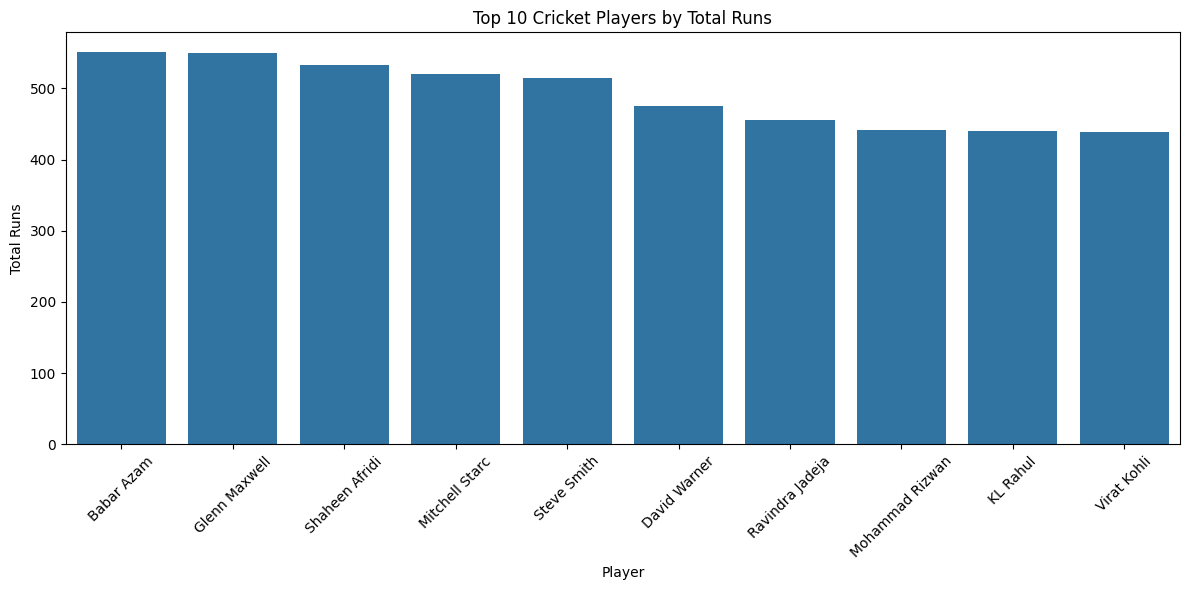

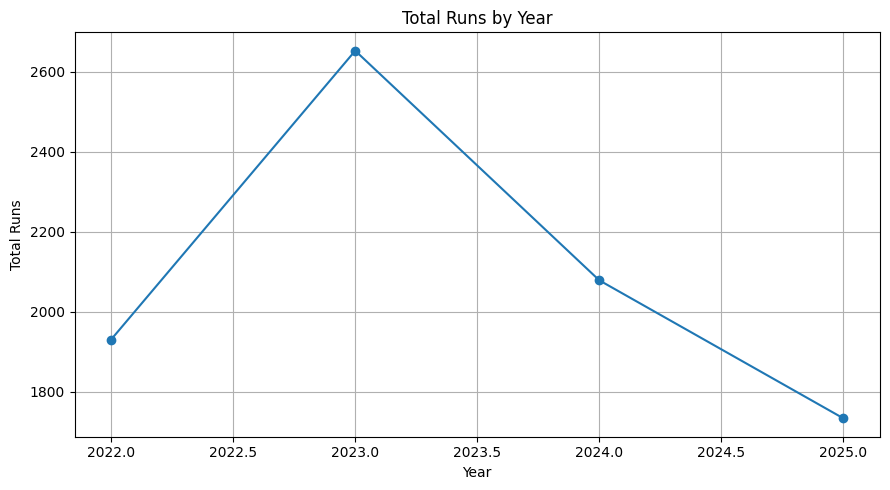

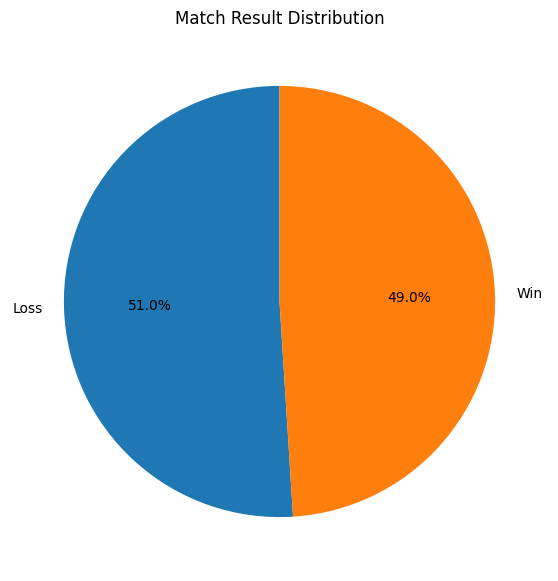

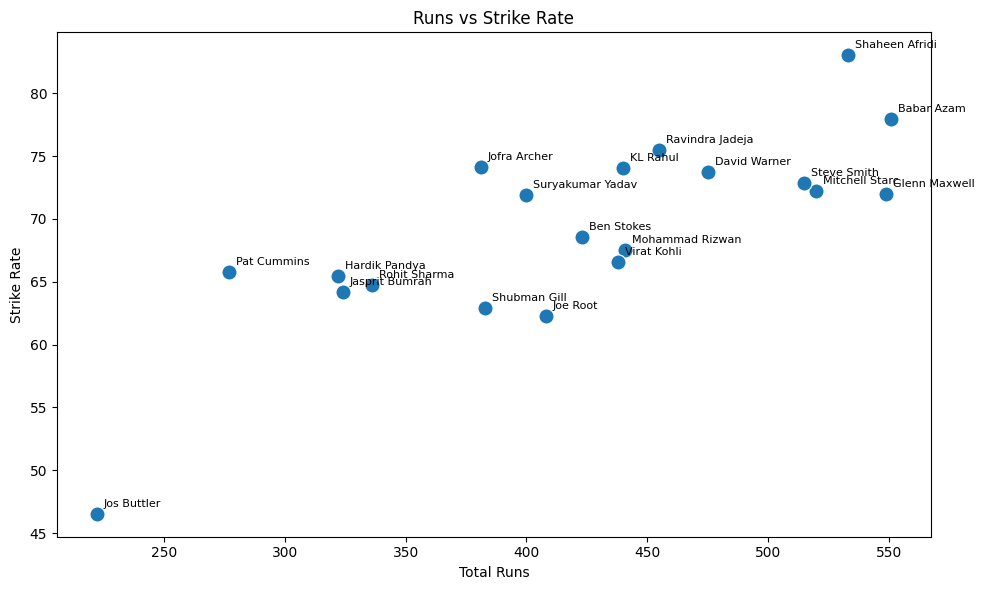

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

df["Date"] = pd.to_datetime(df["Date"])

df["Strike_Rate"] = (
    df["Runs"] / df["Balls_Faced"] * 100
).round(2)

df["Win"] = (df["Match_Result"] == "Win").astype(int)

player_runs = (
    df.groupby("Player")["Runs"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=player_runs.index,
    y=player_runs.values
)
plt.title("Top 10 Cricket Players by Total Runs")
plt.xlabel("Player")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


year_runs = (
    df.groupby(df["Date"].dt.year)["Runs"]
    .sum()
)

plt.figure(figsize=(9, 5))
plt.plot(
    year_runs.index,
    year_runs.values,
    marker="o"
)
plt.title("Total Runs by Year")
plt.xlabel("Year")
plt.ylabel("Total Runs")
plt.grid(True)
plt.tight_layout()
plt.show()


result_count = df["Match_Result"].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    result_count.values,
    labels=result_count.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Match Result Distribution")
plt.show()


player_analysis = (
    df.groupby("Player")
    .agg(
        Runs=("Runs", "sum"),
        Balls_Faced=("Balls_Faced", "sum")
    )
    .reset_index()
)

player_analysis["Strike_Rate"] = (
    player_analysis["Runs"] /
    player_analysis["Balls_Faced"] * 100
).round(2)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=player_analysis,
    x="Runs",
    y="Strike_Rate",
    s=120
)

for _, row in player_analysis.iterrows():
    plt.annotate(
        row["Player"],
        (row["Runs"], row["Strike_Rate"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.title("Runs vs Strike Rate")
plt.xlabel("Total Runs")
plt.ylabel("Strike Rate")
plt.tight_layout()
plt.show()


interactive_data = (
    df.groupby(["Player", "Team"])
    .agg(
        Runs=("Runs", "sum"),
        Wickets=("Wickets", "sum"),
        Matches=("Match_ID", "nunique")
    )
    .reset_index()
)

interactive_data["Strike_Rate"] = (
    interactive_data["Runs"] /
    df.groupby(["Player", "Team"])["Balls_Faced"].sum().values
    * 100
).round(2)

fig = px.bar(
    interactive_data.sort_values(
        "Runs",
        ascending=False
    ),
    x="Player",
    y="Runs",
    color="Team",
    hover_data=[
        "Matches",
        "Wickets",
        "Strike_Rate"
    ],
    title="Interactive Cricket Player Performance"
)

fig.show()